# Lesson 5: Recurrent Neural Networks: Sequence Prediction

In this homework, you will create a *synthetic* dataset based on some simple mathematical functions. 

Then, you will design an RNN architecture that can read several function values in a row (*e.g.*, the values of the function at time points 0, 1, 2, 3, 4) and predict the next value (*e.g.*, the value of the function at time point 5).

First, though, our usual cast of imports.

In [1]:
%matplotlib inline

from keras.models import Model, Sequential
from keras.layers import LSTM, Dense
from keras.regularizers import l1_l2
import math
import numpy as np

import matplotlib.pyplot as plt

2023-09-12 20:30:16.765010: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


**NOTE:** If we haven't covered it fully at the time you start working on this assignment, we'll examine in detail what an *LSTM* is, and how one works, shortly.  For the purposes of the current assignment, you can think of an LSTM as a drop-in replacement for the units we've had in dense layers previously, but unlike those units, the LSTM has some built-in smarts that try to keep gradients flowing happily and overcome some of the ways that RNNs in particular make that problem difficult.

# Setting Up the Input Data for the Problem

In the next few cells, we'll build the data you're going to experiment with.

In [2]:
#Set up params for dataset.
NUM_FREQS = 2       # Number of sine waves to superimpose
SR = 200            # Digital sampling rate in samples per time unit
MAX_FREQ = SR / 2   # Nyquist frequency--if this is mysterious to you,
                    # don't worry about it... we just want to make sure
                    # any sinusoidal components in our signal aren't too
                    # high frequency to represent with fidelity when we
                    # look at a discretely sampled version of the signal.
two_pi = 2 * math.pi

MAX_FREQ /= 4  # Calm the frequencies down a little--pander to Nyquist above.

MAX_X_DATA = 5     # Set x-range from 0 to MAX_X_DATA

TRAIN_TEST_SPLIT = 0.7  # Percentage of data in training set

# Use this to try on random sine waves if you'd like, once you have things
# working.
RANDOMIZE_WAVES = False
if RANDOMIZE_WAVES:
    np.random.seed(42)
    freqs = np.random.rand(NUM_FREQS) * MAX_FREQ
    amplitudes = np.random.rand(NUM_FREQS)
    phases = np.random.rand(NUM_FREQS) * two_pi
    waves = list(zip(freqs, amplitudes, phases))
else:
    # Or just use fixed frequencies etc, to make it easier:
    waves = [(20, .5, 0), (3, .3, 3)]  # Each element is (freq, amplitude, phase)
waves

[(20, 0.5, 0), (3, 0.3, 3)]

If you read through the above you'll see that the function or signal we're planning to try and predict is made by taking two sine waves, each with different frequencies, amplitudes and phase lags, and adding them together. 

We'll visualize the result after we compute it.

In [3]:
# Make the sine wave data...
data = []
t_list = [float(i)/SR for i in range(SR * MAX_X_DATA)]
for t in t_list:
    total = 0
    for freq, A, phase in waves:
        total += A * np.sin(phase + t * freq * two_pi)
    data.append(total)

# normalize the amplitude of the resulting curve...
max_data = abs(np.max(data))
data /= max_data

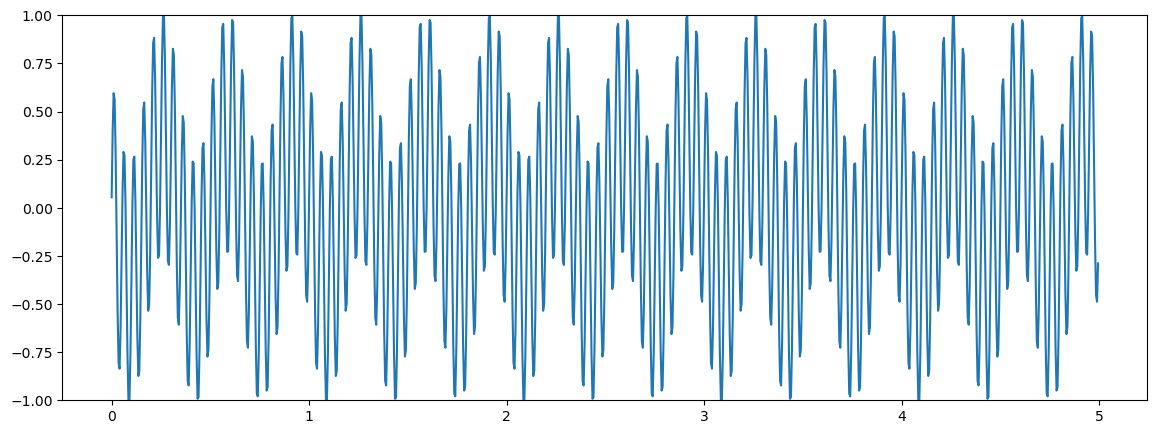

In [4]:
plt.figure(figsize=(14,5))
plt.ylim(-1,1)
plt.plot(t_list, data)
plt.show()

In [5]:
# Make input/output pairs: i.e. match data point at index (N) to data point at index (N+1)
#
# i.e. we want to create a sequence of pairs where each pair contains
#      a value of the function at some time, paired with its successor
#      value in the time sequence.
#
# If the 'zip' function is new to you, consult its Python documentation
# and play with it on a few examples.
#
data_pairs = list(zip(data, data[1:]))

In [6]:
# Have a look at what we've produced so far... I like to do this
# periodically to get a sense of the shapes and types of things as
# I work since Jupyter notebooks don't give you some of the affordances
# you'd expect from a full IDE...
print(f"len(data_pairs) = {len(data_pairs)}")
print(f"First five data_pairs = {data_pairs[:5]}")

len(data_pairs) = 999
First five data_pairs = [(0.054613123426684805, 0.397434783155069), (0.397434783155069, 0.5952831983193219), (0.5952831983193219, 0.5589840731103541), (0.5589840731103541, 0.28885960113327525), (0.28885960113327525, -0.12527439440585547)]


In [7]:
# Divide the data points into training and test sets
split_idx = int(len(data_pairs)*TRAIN_TEST_SPLIT )
train = data_pairs[:split_idx]
test = data_pairs[split_idx:]

# Now we'll splice apart the pairs that were grouped together a couple of
# cells above so that we'll have a sequence value x and its corresponding
# successor value y
train_x = np.array([x[0] for x in train])
train_y = np.array([x[1] for x in train])
# Do some reshaping:
train_x = np.reshape(train_x, (len(train_x), 1, 1))  # batch, #prev_context, #input nodes
train_y = np.reshape(train_y, (len(train_y), 1))     # batch, #prev_context, #output nodes

# Do the same steps for the data points in the test set...
test_x = np.array([x[0] for x in test])
test_y = np.array([x[1] for x in test])
test_x = np.reshape(test_x, (len(test_x), 1, 1))  # batch, #prev_context, #input nodes
test_y = np.reshape(test_y, (len(test_y), 1))     # batch, #prev_context, #output nodes

# Check the shapes of things
train_x.shape, train_y.shape, len(test)

((699, 1, 1), (699, 1), 300)

# Building and Experimenting with Different Models

The cell below contains an example model with a single recurrent layer
containing LSTM units, followed by a small fully connected layer with
ReLU activations and finally a linear activtion to produce the final
regression output.

Treat the model as starter code.  Run it and walk through the plots and
visualizations that follow it and get a sense for what they're doing to
try and help you measure how well your model is working.

How you manage the runs is up to you, but remember that Jupyter notebooks
are stateful, and the model object itself is stateful as well, so you may
want to create different models under different variable names and then
be careful about how you push the results through the *predicted vs. actual*
and *error* plots that are produced below.

When experimenting with this sort of thing by hand, I'll sometimes open
an Excel spreadsheet and use it to document model settings and parameters,
along with some comments while also trying to keep everything in the notebook
nicely named and separated and *easily reset to a known state*.  Also the
code to produce the plots could benefit from being packaged into reusable
functions.  Doing so is often fairly easy, and it's a good sort of hygienic
side task to do while experimenting with ML models in a notebook, especially
since notebooks can invite us to become pretty slovenly, which ultimately
can lead to errors, confusion and frustration.

Out of the gate, the starter model below should produce a result that's
reasonably credible. You should view the purpose of the exercise as understanding
the model's structure, what the model does, what the Keras code that creates the
model means, and what effects altering the architecture and changing regularization,
etc., have.  Throughout, work thoughtfully and keep notes on what you're doing.
Keep asking yourself whether a result seems reasonable or surprising, etc.

In [8]:
# Build LSTM model 1

# The starter code below is just an example.  Tweak things to try
# and improve its performance.  You'll comment on what you did
# later in the notebook.

# TODO: You should produce some number of variations, say three to five,
# on this network, train them, and see how they perform.  You might try
# changing the number of units in the recurrent layer, making a fancier
# fully connected layer following it, trying different regularization
# parameters, etc.
#
NUM_LSTM_NODES = 15
NUM_EPOCHS = 10

model = Sequential()
model.add(LSTM(NUM_LSTM_NODES, 
               batch_input_shape=(1, 1, 1), 
               stateful=True, 
              kernel_regularizer=l1_l2(0)))
model.add(Dense(5, activation='relu'))
model.add(Dense(1, activation='linear'))
model.summary()

# NOTE: We have no regularization in the starting example.
#       We've also set stateful on the LSTM units to be true,
#       so that the last state for each sample at index i in
#       a batch will be used as initial state for the sample
#       of index i in the following batch.  Now might be a
#       good time to review the Keras documentation on any
#       of the settings above that seem mysterious...

2023-09-12 20:30:18.810539: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (1, 15)                   1020      
                                                                 
 dense (Dense)               (1, 5)                    80        
                                                                 
 dense_1 (Dense)             (1, 1)                    6         
                                                                 
Total params: 1,106
Trainable params: 1,106
Non-trainable params: 0
_________________________________________________________________


2023-09-12 20:30:19.063419: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-09-12 20:30:19.065096: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-09-12 20:30:19.066578: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

In [9]:
# compile model
model.compile(loss='mse', 
              optimizer='adam'
             )

In [10]:
# fit() the model
#
# It's worth looking at the call to fit() itself, as well as anything
# else we're doing nearby, to make sure you feel comfortable with
# what it's doing...

for i in range(NUM_EPOCHS):
    print("Epoch %d" % i)
    model.fit(train_x, train_y, # training inputs and targets
              batch_size=1,
              epochs=1, 
              shuffle=False, # we don't want to shuffle, think about why? 
              verbose=1)
    # We reset the *hidden* states after each full pass through the training data...
    model.reset_states()

Epoch 0


2023-09-12 20:30:19.427370: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-09-12 20:30:19.429191: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-09-12 20:30:19.430616: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

699/699 [==============================] - 3s 2ms/step - loss: 0.1566
Epoch 1
699/699 [==============================] - 1s 2ms/step - loss: 0.0416
Epoch 2
699/699 [==============================] - 2s 2ms/step - loss: 0.0316
Epoch 3
699/699 [==============================] - 1s 2ms/step - loss: 0.0324
Epoch 4
699/699 [==============================] - 2s 2ms/step - loss: 0.0115
Epoch 5
699/699 [==============================] - 1s 2ms/step - loss: 0.0120
Epoch 6
699/699 [==============================] - 1s 2ms/step - loss: 0.0057
Epoch 7
699/699 [==============================] - 1s 2ms/step - loss: 0.0113
Epoch 8
699/699 [==============================] - 2s 2ms/step - loss: 0.0389
Epoch 9
699/699 [==============================] - 1s 2ms/step - loss: 0.0245


In [11]:
# Before we actually call model.evaluate() on the test set, it's worth
# reviewing the Keras documentation on just what evaluate() does, and
# what it returns. 
# See:
#    https://keras.io/api/models/model_training_apis/#evaluate-method
for m in model.metrics:
    print(m) # Remember which metrics we asked always get and
             # which we asked for...

Mean(name=loss,dtype=float32)


In [12]:
loss_on_test_set = model.evaluate(test_x, test_y, # test inputs and targets
                                  batch_size=1, verbose=0)
model.reset_states()
print(f"Model MSE Loss on Test Set: %f" % loss_on_test_set)

2023-09-12 20:30:44.921158: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-09-12 20:30:44.922935: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-09-12 20:30:44.924285: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

Model MSE Loss on Test Set: 0.023398


In [13]:
# Paste together our predictions alongside the corresponding
# training targets for comparison...
result = []
for i in range(len(test_x)):
    prediction = model.predict(test_x[i].reshape(1,1,1), verbose=0)
    result.append([prediction, test_y[i]])

2023-09-12 20:30:46.002997: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-09-12 20:30:46.004929: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-09-12 20:30:46.006645: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

In [14]:
predictions = [[x[0][0][0], x[1][0]] for x in result]

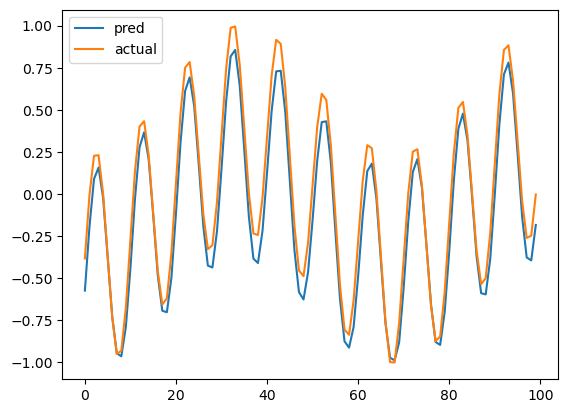

In [15]:
# See how good our predictions did relative to the actual values.
# As you experiment with things like different numbers of units
# in the recurrent layer, or perhaps fancier fully connected stuff
# after the recurrent layer, or types and amounts of regularization,
# you can repeat this process---try to get a sense for how the knobs
# you're turning are affecting things.
plt.plot(predictions[50:150])
plt.legend(('pred', 'actual'))
plt.show()

In [16]:
test_y[:10]

array([[-0.05461312],
       [ 0.36080375],
       [ 0.63157253],
       [ 0.66787165],
       [ 0.46937894],
       [ 0.12527439],
       [-0.21994209],
       [-0.42176077],
       [-0.39097211],
       [-0.12784938]])

In [17]:
errors = [abs(x[1] - x[0]) for x in predictions]

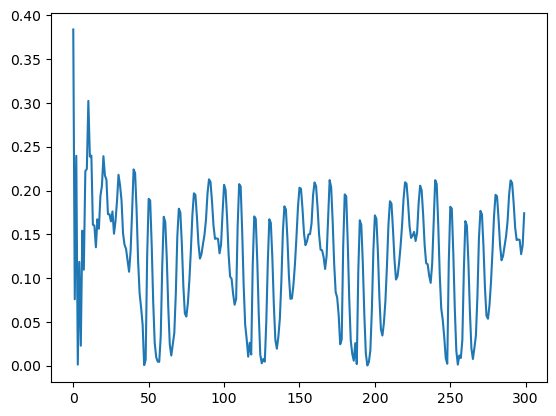

In [18]:
plt.plot(errors)
plt.show()

In [19]:
model.reset_states() # Clear (only!) the hidden states of the network

In [20]:
# LSTM model 2, changing regularization and increasing units

NUM_LSTM_NODES = 15
NUM_EPOCHS = 10

model = Sequential()
from tensorflow.keras.regularizers import l2
model.add(LSTM(NUM_LSTM_NODES, 
               batch_input_shape=(1, 1, 1), 
               stateful=True, 
              kernel_regularizer=l2(0.1)))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='linear'))
model.summary()

# NOTE: We have no regularization in the starting example.
#       We've also set stateful on the LSTM units to be true,
#       so that the last state for each sample at index i in
#       a batch will be used as initial state for the sample
#       of index i in the following batch.  Now might be a
#       good time to review the Keras documentation on any
#       of the settings above that seem mysterious...

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_1 (LSTM)               (1, 15)                   1020      
                                                                 
 dense_2 (Dense)             (1, 10)                   160       
                                                                 
 dense_3 (Dense)             (1, 1)                    11        
                                                                 
Total params: 1,191
Trainable params: 1,191
Non-trainable params: 0
_________________________________________________________________


2023-09-12 20:31:04.656538: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-09-12 20:31:04.658338: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-09-12 20:31:04.659591: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

In [21]:
# compile model
model.compile(loss='mse', 
              optimizer='adam'
             )

In [22]:
# fit() the model

for i in range(NUM_EPOCHS):
    print("Epoch %d" % i)
    model.fit(train_x, train_y, # training inputs and targets
              batch_size=1,
              epochs=1, 
              shuffle=False, # we don't want to shuffle, think about why? 
              verbose=1)
    # We reset the *hidden* states after each full pass through the training data...
    model.reset_states()

Epoch 0


2023-09-12 20:31:04.989320: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-09-12 20:31:04.991113: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-09-12 20:31:04.992540: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

699/699 [==============================] - 3s 2ms/step - loss: 0.2238
Epoch 1
699/699 [==============================] - 1s 2ms/step - loss: 0.0786
Epoch 2
699/699 [==============================] - 1s 2ms/step - loss: 0.0538
Epoch 3
699/699 [==============================] - 1s 2ms/step - loss: 0.0470
Epoch 4
699/699 [==============================] - 2s 2ms/step - loss: 0.0398
Epoch 5
699/699 [==============================] - 2s 2ms/step - loss: 0.0559
Epoch 6
699/699 [==============================] - 2s 2ms/step - loss: 0.0276
Epoch 7
699/699 [==============================] - 2s 2ms/step - loss: 0.0262
Epoch 8
699/699 [==============================] - 1s 2ms/step - loss: 0.0324
Epoch 9
699/699 [==============================] - 2s 2ms/step - loss: 0.0284


In [23]:
for m in model.metrics:
    print(m) # Remember which metrics we asked always get and
             # which we asked for...

Mean(name=loss,dtype=float32)


In [24]:
loss_on_test_set = model.evaluate(test_x, test_y, # test inputs and targets
                                  batch_size=1, verbose=0)
model.reset_states()
print(f"Model MSE Loss on Test Set: %f" % loss_on_test_set)

2023-09-12 20:31:27.964674: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-09-12 20:31:27.966610: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-09-12 20:31:27.967963: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

Model MSE Loss on Test Set: 0.039810


In [25]:
# Paste together our predictions alongside the corresponding
# training targets for comparison...
result = []
for i in range(len(test_x)):
    prediction = model.predict(test_x[i].reshape(1,1,1), verbose=0)
    result.append([prediction, test_y[i]])

2023-09-12 20:31:29.253045: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-09-12 20:31:29.254926: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-09-12 20:31:29.256358: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

In [26]:
predictions = [[x[0][0][0], x[1][0]] for x in result]

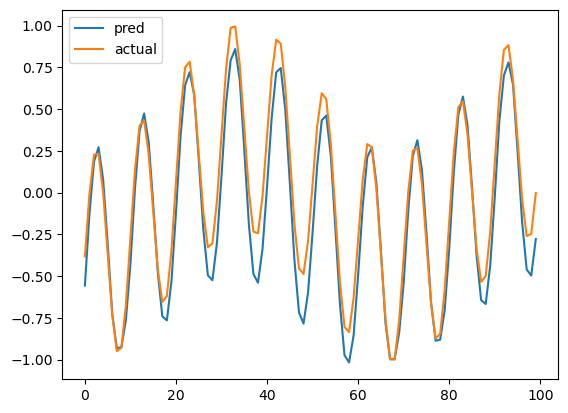

In [27]:
plt.plot(predictions[50:150])
plt.legend(('pred', 'actual'))
plt.show()

In [28]:
test_y[:10]

array([[-0.05461312],
       [ 0.36080375],
       [ 0.63157253],
       [ 0.66787165],
       [ 0.46937894],
       [ 0.12527439],
       [-0.21994209],
       [-0.42176077],
       [-0.39097211],
       [-0.12784938]])

In [29]:
errors = [abs(x[1] - x[0]) for x in predictions]

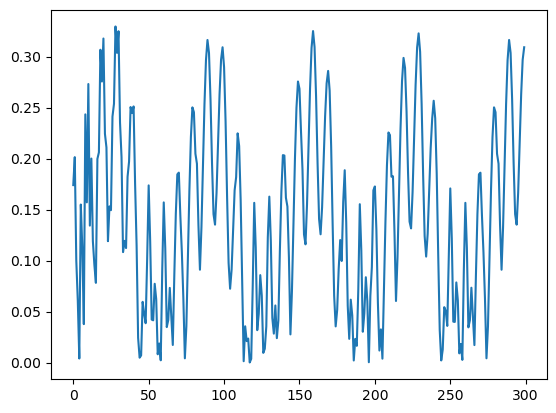

In [30]:
plt.plot(errors)
plt.show()

In [31]:
model.reset_states() # Clear (only!) the hidden states of the network

In [32]:
# LSTM model 3, increasing units, adding a fully connected layer, and implementing regularization

NUM_LSTM_NODES = 15
NUM_EPOCHS = 10

model = Sequential()
model.add(LSTM(NUM_LSTM_NODES, 
               batch_input_shape=(1, 1, 1), 
               stateful=True, 
              kernel_regularizer=l1_l2(0)))
model.add(Dense(10, activation='relu'))
model.add(Dense(10, activation='relu', kernel_regularizer=l2(0.1)))
model.add(Dense(1, activation='linear'))
model.summary()

# NOTE: We have no regularization in the starting example.
#       We've also set stateful on the LSTM units to be true,
#       so that the last state for each sample at index i in
#       a batch will be used as initial state for the sample
#       of index i in the following batch.  Now might be a
#       good time to review the Keras documentation on any
#       of the settings above that seem mysterious...

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_2 (LSTM)               (1, 15)                   1020      
                                                                 
 dense_4 (Dense)             (1, 10)                   160       
                                                                 
 dense_5 (Dense)             (1, 10)                   110       
                                                                 
 dense_6 (Dense)             (1, 1)                    11        
                                                                 
Total params: 1,301
Trainable params: 1,301
Non-trainable params: 0
_________________________________________________________________


2023-09-12 20:31:48.775278: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-09-12 20:31:48.777071: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-09-12 20:31:48.778403: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

In [33]:
# compile model
model.compile(loss='mse', 
              optimizer='adam'
             )

In [34]:
# fit() the model

for i in range(NUM_EPOCHS):
    print("Epoch %d" % i)
    model.fit(train_x, train_y, # training inputs and targets
              batch_size=1,
              epochs=1, 
              shuffle=False, # we don't want to shuffle, think about why? 
              verbose=1)
    # We reset the *hidden* states after each full pass through the training data...
    model.reset_states()

Epoch 0


2023-09-12 20:31:49.108943: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-09-12 20:31:49.110966: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-09-12 20:31:49.112456: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

699/699 [==============================] - 3s 2ms/step - loss: 0.4550
Epoch 1
699/699 [==============================] - 2s 2ms/step - loss: 0.0936
Epoch 2
699/699 [==============================] - 2s 3ms/step - loss: 0.0630
Epoch 3
699/699 [==============================] - 1s 2ms/step - loss: 0.0511
Epoch 4
699/699 [==============================] - 2s 3ms/step - loss: 0.0485
Epoch 5
699/699 [==============================] - 1s 2ms/step - loss: 0.0459
Epoch 6
699/699 [==============================] - 2s 3ms/step - loss: 0.0410
Epoch 7
699/699 [==============================] - 2s 3ms/step - loss: 0.0449
Epoch 8
699/699 [==============================] - 2s 2ms/step - loss: 0.0296
Epoch 9
699/699 [==============================] - 2s 2ms/step - loss: 0.0284


In [35]:
for m in model.metrics:
    print(m) # Remember which metrics we asked always get and
             # which we asked for...

Mean(name=loss,dtype=float32)


In [36]:
loss_on_test_set = model.evaluate(test_x, test_y, # test inputs and targets
                                  batch_size=1, verbose=0)
model.reset_states()
print(f"Model MSE Loss on Test Set: %f" % loss_on_test_set)

2023-09-12 20:32:14.342236: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-09-12 20:32:14.343994: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-09-12 20:32:14.345388: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

Model MSE Loss on Test Set: 0.347009


In [37]:
# Paste together our predictions alongside the corresponding
# training targets for comparison...
result = []
for i in range(len(test_x)):
    prediction = model.predict(test_x[i].reshape(1,1,1), verbose=0)
    result.append([prediction, test_y[i]])

2023-09-12 20:32:15.389244: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-09-12 20:32:15.391170: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-09-12 20:32:15.392564: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

In [38]:
predictions = [[x[0][0][0], x[1][0]] for x in result]

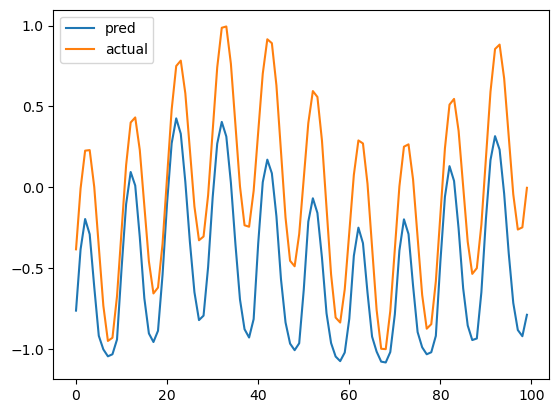

In [39]:
plt.plot(predictions[50:150])
plt.legend(('pred', 'actual'))
plt.show()

In [40]:
test_y[:10]

array([[-0.05461312],
       [ 0.36080375],
       [ 0.63157253],
       [ 0.66787165],
       [ 0.46937894],
       [ 0.12527439],
       [-0.21994209],
       [-0.42176077],
       [-0.39097211],
       [-0.12784938]])

In [41]:
errors = [abs(x[1] - x[0]) for x in predictions]

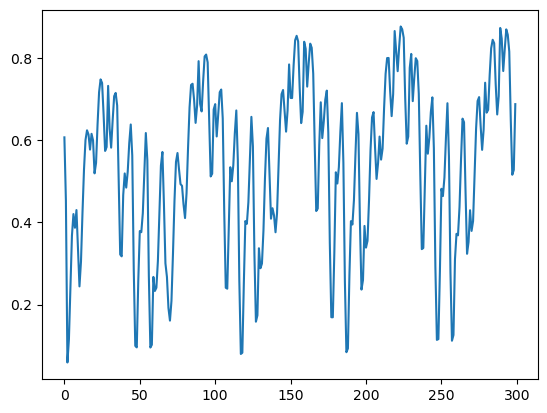

In [42]:
plt.plot(errors)
plt.show()

In [43]:
model.reset_states() # Clear (only!) the hidden states of the network

In [44]:
# LSTM model 4, just adding the fully connected layer and increasing the number of units

NUM_LSTM_NODES = 15
NUM_EPOCHS = 10

model = Sequential()
model.add(LSTM(NUM_LSTM_NODES, 
               batch_input_shape=(1, 1, 1), 
               stateful=True, 
              kernel_regularizer=l1_l2(0)))
model.add(Dense(10, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='linear'))
model.summary()

# NOTE: We have no regularization in the starting example.
#       We've also set stateful on the LSTM units to be true,
#       so that the last state for each sample at index i in
#       a batch will be used as initial state for the sample
#       of index i in the following batch.  Now might be a
#       good time to review the Keras documentation on any
#       of the settings above that seem mysterious...

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_3 (LSTM)               (1, 15)                   1020      
                                                                 
 dense_7 (Dense)             (1, 10)                   160       
                                                                 
 dense_8 (Dense)             (1, 10)                   110       
                                                                 
 dense_9 (Dense)             (1, 1)                    11        
                                                                 
Total params: 1,301
Trainable params: 1,301
Non-trainable params: 0
_________________________________________________________________


2023-09-12 20:32:34.805054: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-09-12 20:32:34.806794: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-09-12 20:32:34.808131: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

In [45]:
# compile model
model.compile(loss='mse', 
              optimizer='adam'
             )

In [46]:
# fit() the model

for i in range(NUM_EPOCHS):
    print("Epoch %d" % i)
    model.fit(train_x, train_y, # training inputs and targets
              batch_size=1,
              epochs=1, 
              shuffle=False, # we don't want to shuffle, think about why? 
              verbose=1)
    # We reset the *hidden* states after each full pass through the training data...
    model.reset_states()

Epoch 0


2023-09-12 20:32:35.128600: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-09-12 20:32:35.130232: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-09-12 20:32:35.131619: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

699/699 [==============================] - 3s 2ms/step - loss: 0.1887
Epoch 1
699/699 [==============================] - 2s 2ms/step - loss: 0.0419
Epoch 2
699/699 [==============================] - 2s 2ms/step - loss: 0.0284
Epoch 3
699/699 [==============================] - 2s 2ms/step - loss: 0.0230
Epoch 4
699/699 [==============================] - 2s 2ms/step - loss: 0.0139
Epoch 5
699/699 [==============================] - 2s 2ms/step - loss: 0.0138
Epoch 6
699/699 [==============================] - 2s 2ms/step - loss: 0.0124
Epoch 7
699/699 [==============================] - 2s 2ms/step - loss: 0.0123
Epoch 8
699/699 [==============================] - 2s 2ms/step - loss: 0.0262
Epoch 9
699/699 [==============================] - 2s 2ms/step - loss: 0.0255


In [47]:
for m in model.metrics:
    print(m) # Remember which metrics we asked always get and
             # which we asked for...

Mean(name=loss,dtype=float32)


In [48]:
loss_on_test_set = model.evaluate(test_x, test_y, # test inputs and targets
                                  batch_size=1, verbose=0)
model.reset_states()
print(f"Model MSE Loss on Test Set: %f" % loss_on_test_set)

2023-09-12 20:32:59.930343: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-09-12 20:32:59.932126: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-09-12 20:32:59.933486: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

Model MSE Loss on Test Set: 1.642253


In [49]:
# Paste together our predictions alongside the corresponding
# training targets for comparison...
result = []
for i in range(len(test_x)):
    prediction = model.predict(test_x[i].reshape(1,1,1), verbose=0)
    result.append([prediction, test_y[i]])

2023-09-12 20:33:00.939134: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-09-12 20:33:00.940941: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-09-12 20:33:00.942193: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

In [50]:
predictions = [[x[0][0][0], x[1][0]] for x in result]

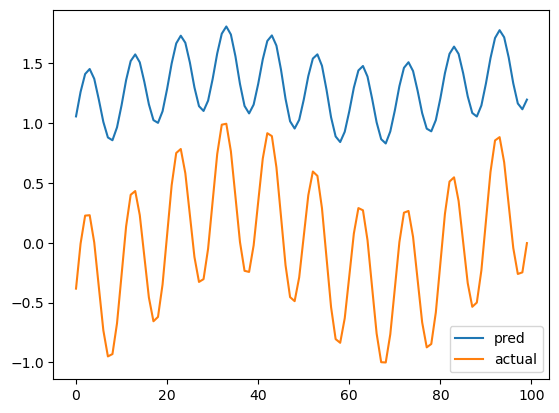

In [51]:
plt.plot(predictions[50:150])
plt.legend(('pred', 'actual'))
plt.show()

In [52]:
test_y[:10]

array([[-0.05461312],
       [ 0.36080375],
       [ 0.63157253],
       [ 0.66787165],
       [ 0.46937894],
       [ 0.12527439],
       [-0.21994209],
       [-0.42176077],
       [-0.39097211],
       [-0.12784938]])

In [53]:
errors = [abs(x[1] - x[0]) for x in predictions]

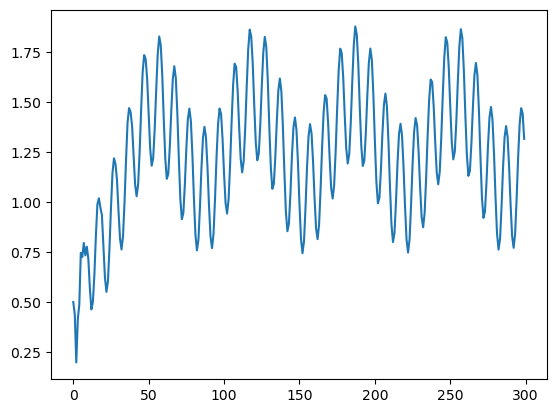

In [54]:
plt.plot(errors)
plt.show()

In [55]:
model.reset_states() # Clear (only!) the hidden states of the network

In [56]:
# LSTM model 5, adding regularization and a fully connected layer

NUM_LSTM_NODES = 15
NUM_EPOCHS = 10

model = Sequential()
model.add(LSTM(NUM_LSTM_NODES, 
               batch_input_shape=(1, 1, 1), 
               stateful=True, 
              kernel_regularizer=l1_l2(0)))
model.add(Dense(5, activation='relu'))
model.add(Dense(5, activation='relu', kernel_regularizer=l2(0.1)))
model.add(Dense(1, activation='linear'))
model.summary()

# NOTE: We have no regularization in the starting example.
#       We've also set stateful on the LSTM units to be true,
#       so that the last state for each sample at index i in
#       a batch will be used as initial state for the sample
#       of index i in the following batch.  Now might be a
#       good time to review the Keras documentation on any
#       of the settings above that seem mysterious...

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_4 (LSTM)               (1, 15)                   1020      
                                                                 
 dense_10 (Dense)            (1, 5)                    80        
                                                                 
 dense_11 (Dense)            (1, 5)                    30        
                                                                 
 dense_12 (Dense)            (1, 1)                    6         
                                                                 
Total params: 1,136
Trainable params: 1,136
Non-trainable params: 0
_________________________________________________________________


2023-09-12 20:33:20.118676: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-09-12 20:33:20.120586: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-09-12 20:33:20.121870: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

In [57]:
# compile model
model.compile(loss='mse', 
              optimizer='adam'
             )

In [58]:
# fit() the model

for i in range(NUM_EPOCHS):
    print("Epoch %d" % i)
    model.fit(train_x, train_y, # training inputs and targets
              batch_size=1,
              epochs=1, 
              shuffle=False, # we don't want to shuffle, think about why? 
              verbose=1)
    # We reset the *hidden* states after each full pass through the training data...
    model.reset_states()

Epoch 0


2023-09-12 20:33:20.496104: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-09-12 20:33:20.498068: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-09-12 20:33:20.499511: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

699/699 [==============================] - 3s 2ms/step - loss: 0.3951
Epoch 1
699/699 [==============================] - 1s 2ms/step - loss: 0.1606
Epoch 2
699/699 [==============================] - 2s 2ms/step - loss: 0.0830
Epoch 3
699/699 [==============================] - 2s 2ms/step - loss: 0.0576
Epoch 4
699/699 [==============================] - 1s 2ms/step - loss: 0.0509
Epoch 5
699/699 [==============================] - 1s 2ms/step - loss: 0.0441
Epoch 6
699/699 [==============================] - 2s 2ms/step - loss: 0.0414
Epoch 7
699/699 [==============================] - 2s 2ms/step - loss: 0.0395
Epoch 8
699/699 [==============================] - 2s 3ms/step - loss: 0.0375
Epoch 9
699/699 [==============================] - 2s 2ms/step - loss: 0.0297


In [59]:
for m in model.metrics:
    print(m) # Remember which metrics we asked always get and
             # which we asked for...

Mean(name=loss,dtype=float32)


In [60]:
loss_on_test_set = model.evaluate(test_x, test_y, # test inputs and targets
                                  batch_size=1, verbose=0)
model.reset_states()
print(f"Model MSE Loss on Test Set: %f" % loss_on_test_set)

2023-09-12 20:33:44.892189: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-09-12 20:33:44.894167: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-09-12 20:33:44.895502: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

Model MSE Loss on Test Set: 0.263936


In [61]:
# Paste together our predictions alongside the corresponding
# training targets for comparison...
result = []
for i in range(len(test_x)):
    prediction = model.predict(test_x[i].reshape(1,1,1), verbose=0)
    result.append([prediction, test_y[i]])

2023-09-12 20:33:45.757548: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-09-12 20:33:45.759263: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-09-12 20:33:45.760655: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

In [62]:
predictions = [[x[0][0][0], x[1][0]] for x in result]

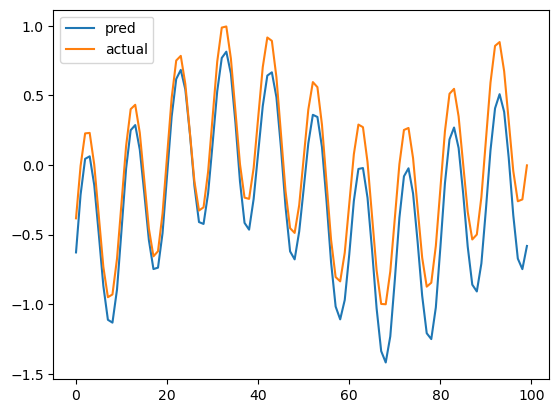

In [63]:
plt.plot(predictions[50:150])
plt.legend(('pred', 'actual'))
plt.show()

In [64]:
test_y[:10]

array([[-0.05461312],
       [ 0.36080375],
       [ 0.63157253],
       [ 0.66787165],
       [ 0.46937894],
       [ 0.12527439],
       [-0.21994209],
       [-0.42176077],
       [-0.39097211],
       [-0.12784938]])

In [65]:
errors = [abs(x[1] - x[0]) for x in predictions]

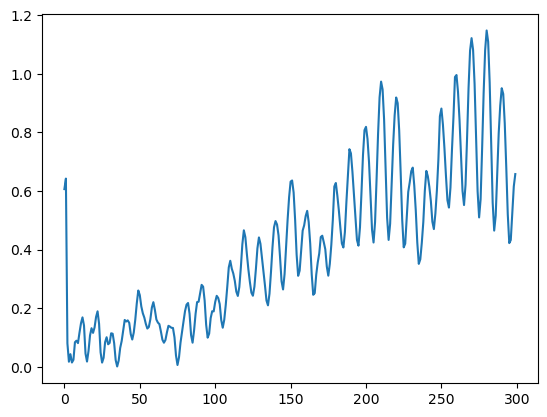

In [66]:
plt.plot(errors)
plt.show()

In [67]:
model.reset_states() # Clear (only!) the hidden states of the network

In [68]:
# LSTM model 6, just increasing the units

NUM_LSTM_NODES = 15
NUM_EPOCHS = 10

model = Sequential()
model.add(LSTM(NUM_LSTM_NODES, 
               batch_input_shape=(1, 1, 1), 
               stateful=True, 
              kernel_regularizer=l1_l2(0)))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='linear'))
model.summary()

# NOTE: We have no regularization in the starting example.
#       We've also set stateful on the LSTM units to be true,
#       so that the last state for each sample at index i in
#       a batch will be used as initial state for the sample
#       of index i in the following batch.  Now might be a
#       good time to review the Keras documentation on any
#       of the settings above that seem mysterious...

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_5 (LSTM)               (1, 15)                   1020      
                                                                 
 dense_13 (Dense)            (1, 10)                   160       
                                                                 
 dense_14 (Dense)            (1, 1)                    11        
                                                                 
Total params: 1,191
Trainable params: 1,191
Non-trainable params: 0
_________________________________________________________________


2023-09-12 20:34:03.108490: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-09-12 20:34:03.110233: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-09-12 20:34:03.111553: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

In [69]:
# compile model
model.compile(loss='mse', 
              optimizer='adam'
             )

In [70]:
# fit() the model

for i in range(NUM_EPOCHS):
    print("Epoch %d" % i)
    model.fit(train_x, train_y, # training inputs and targets
              batch_size=1,
              epochs=1, 
              shuffle=False, # we don't want to shuffle, think about why? 
              verbose=1)
    # We reset the *hidden* states after each full pass through the training data...
    model.reset_states()

Epoch 0


2023-09-12 20:34:03.425395: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-09-12 20:34:03.427041: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-09-12 20:34:03.428529: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

699/699 [==============================] - 3s 2ms/step - loss: 0.1786
Epoch 1
699/699 [==============================] - 2s 2ms/step - loss: 0.0446
Epoch 2
699/699 [==============================] - 2s 2ms/step - loss: 0.0272
Epoch 3
699/699 [==============================] - 2s 2ms/step - loss: 0.0303
Epoch 4
699/699 [==============================] - 2s 2ms/step - loss: 0.0310
Epoch 5
699/699 [==============================] - 1s 2ms/step - loss: 0.0225
Epoch 6
699/699 [==============================] - 2s 2ms/step - loss: 0.0194
Epoch 7
699/699 [==============================] - 2s 3ms/step - loss: 0.0257
Epoch 8
699/699 [==============================] - 2s 2ms/step - loss: 0.0115
Epoch 9
699/699 [==============================] - 2s 2ms/step - loss: 0.0312


In [71]:
for m in model.metrics:
    print(m) # Remember which metrics we asked always get and
             # which we asked for...

Mean(name=loss,dtype=float32)


In [72]:
loss_on_test_set = model.evaluate(test_x, test_y, # test inputs and targets
                                  batch_size=1, verbose=0)
model.reset_states()
print(f"Model MSE Loss on Test Set: %f" % loss_on_test_set)

2023-09-12 20:34:23.859579: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-09-12 20:34:23.861514: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-09-12 20:34:23.862901: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

Model MSE Loss on Test Set: 0.028493


In [73]:
# Paste together our predictions alongside the corresponding
# training targets for comparison...
result = []
for i in range(len(test_x)):
    prediction = model.predict(test_x[i].reshape(1,1,1), verbose=0)
    result.append([prediction, test_y[i]])

2023-09-12 20:34:25.569440: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-09-12 20:34:25.571210: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-09-12 20:34:25.572631: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

In [74]:
predictions = [[x[0][0][0], x[1][0]] for x in result]

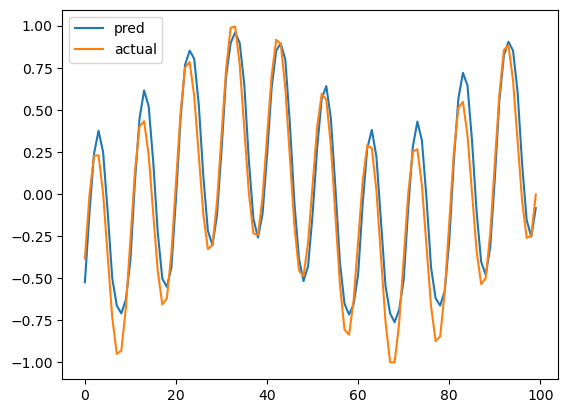

In [75]:
plt.plot(predictions[50:150])
plt.legend(('pred', 'actual'))
plt.show()

In [76]:
test_y[:10]

array([[-0.05461312],
       [ 0.36080375],
       [ 0.63157253],
       [ 0.66787165],
       [ 0.46937894],
       [ 0.12527439],
       [-0.21994209],
       [-0.42176077],
       [-0.39097211],
       [-0.12784938]])

In [77]:
errors = [abs(x[1] - x[0]) for x in predictions]

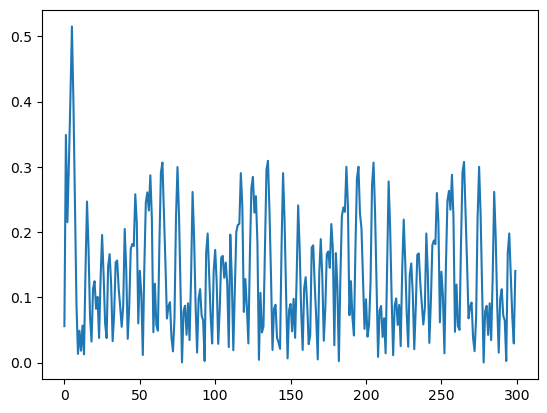

In [78]:
plt.plot(errors)
plt.show()

In [79]:
model.reset_states() # Clear (only!) the hidden states of the network

In [80]:
# LSTM model 7, just increasing the LSTM units

NUM_LSTM_NODES = 30
NUM_EPOCHS = 10

model = Sequential()
model.add(LSTM(NUM_LSTM_NODES, 
               batch_input_shape=(1, 1, 1), 
               stateful=True, 
              kernel_regularizer=l1_l2(0)))
model.add(Dense(5, activation='relu'))
model.add(Dense(1, activation='linear'))
model.summary()

# NOTE: We have no regularization in the starting example.
#       We've also set stateful on the LSTM units to be true,
#       so that the last state for each sample at index i in
#       a batch will be used as initial state for the sample
#       of index i in the following batch.  Now might be a
#       good time to review the Keras documentation on any
#       of the settings above that seem mysterious...

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_6 (LSTM)               (1, 30)                   3840      
                                                                 
 dense_15 (Dense)            (1, 5)                    155       
                                                                 
 dense_16 (Dense)            (1, 1)                    6         
                                                                 
Total params: 4,001
Trainable params: 4,001
Non-trainable params: 0
_________________________________________________________________


2023-09-12 20:34:44.860018: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-09-12 20:34:44.861886: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-09-12 20:34:44.863240: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

In [81]:
# compile model
model.compile(loss='mse', 
              optimizer='adam'
             )

In [82]:
# fit() the model

for i in range(NUM_EPOCHS):
    print("Epoch %d" % i)
    model.fit(train_x, train_y, # training inputs and targets
              batch_size=1,
              epochs=1, 
              shuffle=False, # we don't want to shuffle, think about why? 
              verbose=1)
    # We reset the *hidden* states after each full pass through the training data...
    model.reset_states()

Epoch 0


2023-09-12 20:34:45.181863: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-09-12 20:34:45.183712: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-09-12 20:34:45.185096: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

699/699 [==============================] - 3s 2ms/step - loss: 0.1361
Epoch 1
699/699 [==============================] - 2s 3ms/step - loss: 0.0279
Epoch 2
699/699 [==============================] - 1s 2ms/step - loss: 0.0155
Epoch 3
699/699 [==============================] - 2s 2ms/step - loss: 0.0134
Epoch 4
699/699 [==============================] - 2s 3ms/step - loss: 0.0156
Epoch 5
699/699 [==============================] - 2s 2ms/step - loss: 0.0156
Epoch 6
699/699 [==============================] - 1s 2ms/step - loss: 0.0076
Epoch 7
699/699 [==============================] - 2s 2ms/step - loss: 0.0067
Epoch 8
699/699 [==============================] - 1s 2ms/step - loss: 0.0074
Epoch 9
699/699 [==============================] - 1s 2ms/step - loss: 0.0058


In [83]:
for m in model.metrics:
    print(m) # Remember which metrics we asked always get and
             # which we asked for...

Mean(name=loss,dtype=float32)


In [84]:
loss_on_test_set = model.evaluate(test_x, test_y, # test inputs and targets
                                  batch_size=1, verbose=0)
model.reset_states()
print(f"Model MSE Loss on Test Set: %f" % loss_on_test_set)

2023-09-12 20:35:09.706853: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-09-12 20:35:09.708883: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-09-12 20:35:09.710307: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

Model MSE Loss on Test Set: 0.007596


In [85]:
# Paste together our predictions alongside the corresponding
# training targets for comparison...
result = []
for i in range(len(test_x)):
    prediction = model.predict(test_x[i].reshape(1,1,1), verbose=0)
    result.append([prediction, test_y[i]])

2023-09-12 20:35:10.709114: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-09-12 20:35:10.710943: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-09-12 20:35:10.712315: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

In [86]:
predictions = [[x[0][0][0], x[1][0]] for x in result]

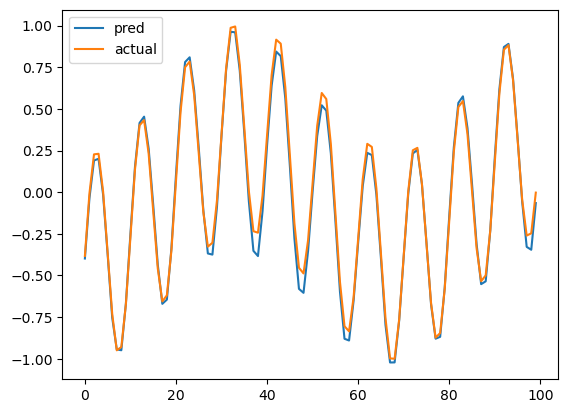

In [87]:
plt.plot(predictions[50:150])
plt.legend(('pred', 'actual'))
plt.show()

In [88]:
test_y[:10]

array([[-0.05461312],
       [ 0.36080375],
       [ 0.63157253],
       [ 0.66787165],
       [ 0.46937894],
       [ 0.12527439],
       [-0.21994209],
       [-0.42176077],
       [-0.39097211],
       [-0.12784938]])

In [89]:
errors = [abs(x[1] - x[0]) for x in predictions]

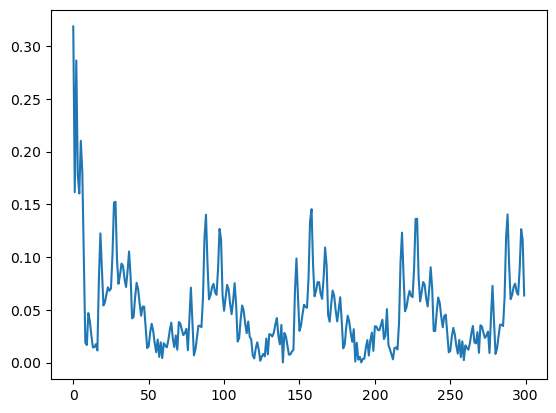

In [90]:
plt.plot(errors)
plt.show()

In [91]:
model.reset_states() # Clear (only!) the hidden states of the network

In [92]:
# LSTM model 8, increasing the LSTM units and adding regularization

NUM_LSTM_NODES = 30
NUM_EPOCHS = 10

model = Sequential()
model.add(LSTM(NUM_LSTM_NODES, 
               batch_input_shape=(1, 1, 1), 
               stateful=True, 
              kernel_regularizer=l1_l2(0)))
model.add(Dense(5, activation='relu', kernel_regularizer=l2(0.1)))
model.add(Dense(1, activation='linear'))
model.summary()

# NOTE: We have no regularization in the starting example.
#       We've also set stateful on the LSTM units to be true,
#       so that the last state for each sample at index i in
#       a batch will be used as initial state for the sample
#       of index i in the following batch.  Now might be a
#       good time to review the Keras documentation on any
#       of the settings above that seem mysterious...

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_7 (LSTM)               (1, 30)                   3840      
                                                                 
 dense_17 (Dense)            (1, 5)                    155       
                                                                 
 dense_18 (Dense)            (1, 1)                    6         
                                                                 
Total params: 4,001
Trainable params: 4,001
Non-trainable params: 0
_________________________________________________________________


2023-09-12 20:35:34.101971: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-09-12 20:35:34.103954: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-09-12 20:35:34.105213: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

In [93]:
# compile model
model.compile(loss='mse', 
              optimizer='adam'
             )

In [94]:
# fit() the model

for i in range(NUM_EPOCHS):
    print("Epoch %d" % i)
    model.fit(train_x, train_y, # training inputs and targets
              batch_size=1,
              epochs=1, 
              shuffle=False, # we don't want to shuffle, think about why? 
              verbose=1)
    # We reset the *hidden* states after each full pass through the training data...
    model.reset_states()

Epoch 0


2023-09-12 20:35:34.432390: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-09-12 20:35:34.434354: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-09-12 20:35:34.435905: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

699/699 [==============================] - 3s 2ms/step - loss: 0.3581
Epoch 1
699/699 [==============================] - 2s 3ms/step - loss: 0.0967
Epoch 2
699/699 [==============================] - 2s 3ms/step - loss: 0.0737
Epoch 3
699/699 [==============================] - 2s 2ms/step - loss: 0.0632
Epoch 4
699/699 [==============================] - 2s 3ms/step - loss: 0.0596
Epoch 5
699/699 [==============================] - 2s 3ms/step - loss: 0.0602
Epoch 6
699/699 [==============================] - 2s 2ms/step - loss: 0.0955
Epoch 7
699/699 [==============================] - 2s 2ms/step - loss: 0.0685
Epoch 8
699/699 [==============================] - 2s 2ms/step - loss: 0.0879
Epoch 9
699/699 [==============================] - 2s 2ms/step - loss: 0.0475


In [95]:
for m in model.metrics:
    print(m) # Remember which metrics we asked always get and
             # which we asked for...

Mean(name=loss,dtype=float32)


In [96]:
loss_on_test_set = model.evaluate(test_x, test_y, # test inputs and targets
                                  batch_size=1, verbose=0)
model.reset_states()
print(f"Model MSE Loss on Test Set: %f" % loss_on_test_set)

2023-09-12 20:35:59.890800: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-09-12 20:35:59.892512: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-09-12 20:35:59.893852: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

Model MSE Loss on Test Set: 0.043072


In [97]:
# Paste together our predictions alongside the corresponding
# training targets for comparison...
result = []
for i in range(len(test_x)):
    prediction = model.predict(test_x[i].reshape(1,1,1), verbose=0)
    result.append([prediction, test_y[i]])

2023-09-12 20:36:00.946274: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-09-12 20:36:00.948197: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-09-12 20:36:00.949471: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

In [98]:
predictions = [[x[0][0][0], x[1][0]] for x in result]

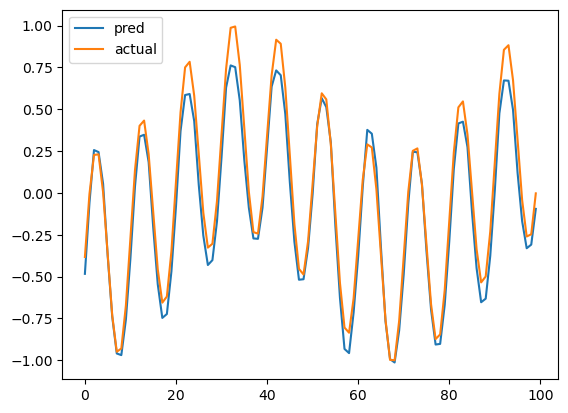

In [99]:
plt.plot(predictions[50:150])
plt.legend(('pred', 'actual'))
plt.show()

In [100]:
test_y[:10]

array([[-0.05461312],
       [ 0.36080375],
       [ 0.63157253],
       [ 0.66787165],
       [ 0.46937894],
       [ 0.12527439],
       [-0.21994209],
       [-0.42176077],
       [-0.39097211],
       [-0.12784938]])

In [101]:
errors = [abs(x[1] - x[0]) for x in predictions]

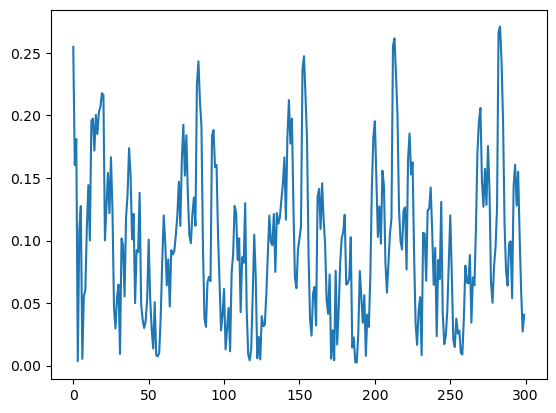

In [102]:
plt.plot(errors)
plt.show()

In [103]:
model.reset_states() # Clear (only!) the hidden states of the network

In [104]:
# LSTM model 9, increasing the LSTM units and units in dense layer

NUM_LSTM_NODES = 30
NUM_EPOCHS = 10

model = Sequential()
model.add(LSTM(NUM_LSTM_NODES, 
               batch_input_shape=(1, 1, 1), 
               stateful=True, 
              kernel_regularizer=l1_l2(0)))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='linear'))
model.summary()

# NOTE: We have no regularization in the starting example.
#       We've also set stateful on the LSTM units to be true,
#       so that the last state for each sample at index i in
#       a batch will be used as initial state for the sample
#       of index i in the following batch.  Now might be a
#       good time to review the Keras documentation on any
#       of the settings above that seem mysterious...

Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_8 (LSTM)               (1, 30)                   3840      
                                                                 
 dense_19 (Dense)            (1, 10)                   310       
                                                                 
 dense_20 (Dense)            (1, 1)                    11        
                                                                 
Total params: 4,161
Trainable params: 4,161
Non-trainable params: 0
_________________________________________________________________


2023-09-12 20:52:21.628261: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-09-12 20:52:21.630073: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-09-12 20:52:21.631260: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

In [105]:
# compile model
model.compile(loss='mse', 
              optimizer='adam'
             )

In [106]:
# fit() the model

for i in range(NUM_EPOCHS):
    print("Epoch %d" % i)
    model.fit(train_x, train_y, # training inputs and targets
              batch_size=1,
              epochs=1, 
              shuffle=False, # we don't want to shuffle, think about why? 
              verbose=1)
    # We reset the *hidden* states after each full pass through the training data...
    model.reset_states()

Epoch 0


2023-09-12 20:52:22.508424: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-09-12 20:52:22.510305: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-09-12 20:52:22.511801: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

699/699 [==============================] - 3s 2ms/step - loss: 0.1346
Epoch 1
699/699 [==============================] - 2s 2ms/step - loss: 0.0325
Epoch 2
699/699 [==============================] - 1s 2ms/step - loss: 0.0138
Epoch 3
699/699 [==============================] - 2s 2ms/step - loss: 0.0208
Epoch 4
699/699 [==============================] - 1s 2ms/step - loss: 0.0190
Epoch 5
699/699 [==============================] - 1s 2ms/step - loss: 0.0092
Epoch 6
699/699 [==============================] - 2s 2ms/step - loss: 0.0089
Epoch 7
699/699 [==============================] - 1s 2ms/step - loss: 0.0163
Epoch 8
699/699 [==============================] - 1s 2ms/step - loss: 0.0150
Epoch 9
699/699 [==============================] - 2s 2ms/step - loss: 0.0122


In [107]:
for m in model.metrics:
    print(m) # Remember which metrics we asked always get and
             # which we asked for...

Mean(name=loss,dtype=float32)


In [108]:
loss_on_test_set = model.evaluate(test_x, test_y, # test inputs and targets
                                  batch_size=1, verbose=0)
model.reset_states()
print(f"Model MSE Loss on Test Set: %f" % loss_on_test_set)

2023-09-12 20:52:46.148970: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-09-12 20:52:46.150784: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-09-12 20:52:46.152098: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

Model MSE Loss on Test Set: 0.026351


In [109]:
# Paste together our predictions alongside the corresponding
# training targets for comparison...
result = []
for i in range(len(test_x)):
    prediction = model.predict(test_x[i].reshape(1,1,1), verbose=0)
    result.append([prediction, test_y[i]])

2023-09-12 20:52:47.069360: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-09-12 20:52:47.071175: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-09-12 20:52:47.072408: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

In [110]:
predictions = [[x[0][0][0], x[1][0]] for x in result]

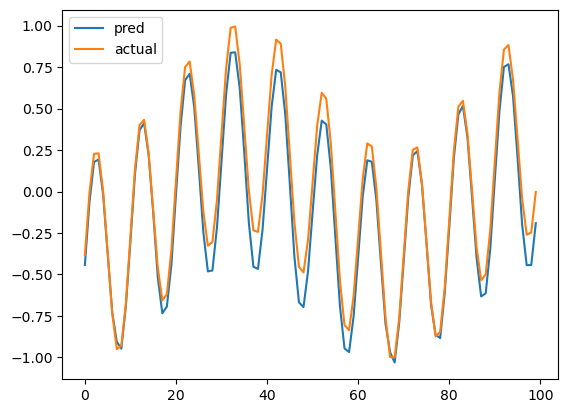

In [111]:
plt.plot(predictions[50:150])
plt.legend(('pred', 'actual'))
plt.show()

In [112]:
test_y[:10]

array([[-0.05461312],
       [ 0.36080375],
       [ 0.63157253],
       [ 0.66787165],
       [ 0.46937894],
       [ 0.12527439],
       [-0.21994209],
       [-0.42176077],
       [-0.39097211],
       [-0.12784938]])

In [113]:
errors = [abs(x[1] - x[0]) for x in predictions]

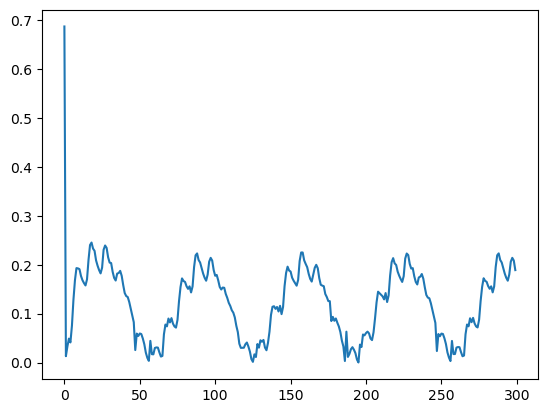

In [114]:
plt.plot(errors)
plt.show()

In [115]:
model.reset_states() # Clear (only!) the hidden states of the network

# Question 1:

- Describe the models you tried out, what motivated you to try each one, and discuss the results you obtained from each.
### I tried changing regularization in the dense layers, increasing the units in the dense layers as well as the LSTM layer, as well as adding an additional dense layer. I ended up working with 8 models including the original, while most of my changes to the dense layers didn't improve the model's performance and ended up doing more harm than good. My model 4 did exceptionally bad and the changes made were adding a dense layer as well as increasing the number of units in those dense layers, when compared to the original I can see the drastic differences in performance, specifically when comparing the MSE loss which was 1.64... compared to 0.023... which is two magnitudes of difference. Futher, my models 2 and 5 also experimented with adding additional dense layers and both of these models did poorly, with both of them being the second and third worst performing models (MSE losses were 0.34... and 0.26... respectively). It became clear that increasing the number of units in the LSTM layer and not the dense layers was key to improving performance because the MSE losses from models 7 versus that of 9 indicates exactly this with a value of 0.007... versus 0.026... respectively.
- What sorts of changes and techniques did you try to improve your predictions?
### I tried changing the number of units, adding layers, and adding regularization.
- What things did you find challenging or surprising?
### The models all ran without issue so nothing was neccesarily challenging, but what was surprising is how bad model 4 did.
- Which model worked best? How well would you say it worked?
### I would say my model 7 worked the best due to how small it's MSE loss was compared to the other eight models.

# Question 2:

- What problems did you run into?
### I didn't run into any considerable problems other than the normal difficulties that come with trouble shooting model parameters in an effort to find the most optimal ones. 

# Question 3:

When you think about it, the function we're trying to predict can be describe with *very few* parameters, assuming we have some notion of what a sinusoid is, and some notion of what sums of sinusoids are.  When we make our function by adding two sinusoids there is in some sense about six degrees of freedom to work with, namely the amplitudes, frequencies and phases of the two curves being added.  Thus if we were using an explicit representation where the process producing our input data distribution was literally summing sinusoids with those few selected parameters, we'd have a very good, very low dimensional representation, that *exactly* replicated what we were trying to predict.  This representation is not far from what you'd get from Fourier analysis (if you've seen that elsewhere) a tool widely used in signal processing, data analysis, data compression and many other applications.

Look at the number of parameters in the summaries of each of the models you produced.  In particular look at the one that did the best at producing a predicted curve that hugged the actual curve and look at the MSE that was associated with it.  What are your thoughts on how many parameters are in play here?

Remember: much of deep learning is about finding semi-automatic ways to find practical representations for real phenomena produced by some kind of process out in the world, where by practical we mean small enough to compute on, yet expressive enough to capture enough of the essence of the phenomena of interest that the representations can be made to do useful work for us.
### The model that performed the best was also one of the models that had the most parameters ironically, most of the models had around 1,100 to 1,300 parameters but the model that performed the best had around 4,000 parameters. Again it performed the best even though it had this many parameters, we can see this by reviewing it's MSE loss relative to the other models, 0.007... compared to the second lowest, 0.023...